[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/18_document_ai_and_observability.ipynb)

# 📓 Notebook 18 (fast track) — Document AI & Observability

> **Module:** AI Engineering · **Estimated time:** 70–85 min · **Difficulty:** Intermediate

Two of the most valuable — and most *quietly dangerous* — things you can do with an LLM are **pull structured data out of messy documents** and **know whether that (or any) AI feature is actually working**. This notebook does both, back to back.

It is a **trimmed fast-track copy combining two canonical chapters**:
[`06_ai_engineering/25_document_processing.ipynb`](../06_ai_engineering/25_document_processing.ipynb) and
[`06_ai_engineering/26_ai_evaluation_observability.ipynb`](../06_ai_engineering/26_ai_evaluation_observability.ipynb).
The deepest stretch material and bonus mini-projects have been dropped to keep it under ~85 minutes; open the canonical chapters when you want the full treatment.

> 🎯 **Our running story: the ops inbox.** A small business inbox fills up overnight with two kinds of mess — **purchase receipts** that need to become clean accounting rows, and **support messages** that need triaging. In **Part 1** we turn receipts into a tidy table; in **Part 2** we build the discipline to trust that pipeline (and the triage feature) in production.

> 🧭 **Mental model — two rules, one habit.** (1) **Extract structure, then TRUST NOTHING until validated.** An LLM will hand back a plausible-looking record; a *wrong* total or a truncated ID looks exactly like a right one. Validation is the quality-control inspector at the end of the belt. (2) **You cannot improve what you do not measure — golden set first, prompt second.** Before you tune a prompt, freeze a handful of known-correct examples; the number they produce is the only honest signal that a change helped. Keep both in mind and every section below is just "which safeguard are we building now?"

> ✅ **Prerequisites.** Fast-track **NB 10** (AI workflows — calling an LLM, structured JSON output, `try/except` parsing) and **NB 11** (embeddings & RAG). Helpful: comfort with pandas and dataclasses.

> 🏎️ **You're on the fast track.** This single notebook stitches together the two canonical chapters listed above. What's trimmed: the PDF/`pypdf` + chunking deep-dives from NB 25, the A/B-testing statistics and several ⭐⭐⭐ stretches from NB 26, and both 🎁 bonus mini-projects. What's kept: the full extract → validate → measure spine of each. Open the canonical versions once you want the deeper material.

## 🔌 Runs entirely offline

Every cell uses an offline **`MockLLM`** (from the repo-root `llm_providers.py`) that returns deterministic answers with no API key and no internet. Swapping in a real OpenAI / Anthropic / Gemini / Ollama client is a one-line change — the rest of the notebook is identical.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Synthesise document-like text and **extract typed fields** from it with a structured-output prompt.
2. Parse model output **defensively** — always wrap `json.loads` in `try/except`.
3. **Validate** an extracted record against a dataclass + schema (types and ranges) — and see why validation is *not* the same as correctness.
4. Assemble extracted records into a **pandas DataFrame** and report **field-level accuracy** against ground truth.
5. Build a **golden set** and score an AI feature with **overall + per-class** metrics.
6. Run an **LLM-as-judge** pass on free-text output — and name its biases.
7. **Trace** every call (prompt hash, tokens, latency, cost) into a DataFrame **cost dashboard**.
8. Write a **regression test** that refuses to ship when quality drops.

## 0. Setup — the offline `MockLLM`

Run this first: it locates the repo-root `llm_providers.py` (one level up from `fast_track/`, or downloads it on Colab) and gives us a deterministic `llm` object. Every later cell uses it.

In [1]:
# MockLLM lives in llm_providers.py so every AI notebook uses the same one.
# Swap it for any real provider by changing this one line — the rest of the
# notebook stays identical:
#
#     from llm_providers import OpenAILLM as LLM      # needs `pip install openai`
#     from llm_providers import AnthropicLLM as LLM   # needs `pip install anthropic`
#     from llm_providers import GoogleLLM as LLM      # needs `pip install google-generativeai`
#     from llm_providers import OllamaLLM as LLM      # local — needs Ollama running
import json, re, random, time
from textwrap import shorten

# Make the repo-root llm_providers.py importable no matter which folder
# Jupyter launched from (it lives one level up, at the course root).
import sys, pathlib
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "llm_providers.py").exists()), None)
if _root:                       # local checkout — use the repo's module
    sys.path.insert(0, str(_root))
else:                           # Colab / standalone — fetch it next to the notebook
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/ChrisW09/Python-for-AI-Driven-Automation"
        "/main/llm_providers.py", "llm_providers.py")
from llm_providers import MockLLM

llm = MockLLM(seed=42)
print('MockLLM ready ✅')

MockLLM ready ✅


> 🔌 **Using a real provider (OpenAI / Anthropic / Gemini / Ollama).**
> Every notebook in this module uses an offline `MockLLM` by default so you can run them without internet or API keys. Once you want real intelligence in the answers, swap one line — the unified interface in [`llm_providers.py`](../llm_providers.py) lets you use **OpenAI**, **Anthropic** (Claude), **Google** (Gemini), or a **local model via Ollama** without changing anything else.
> See the [LLM Providers Guide](../06_ai_engineering/A1_llm_providers_guide.ipynb) for the swap-in instructions, model recommendations, and cost estimates.

In [2]:
# The data-science tools we'll lean on throughout (extracted records -> tables -> charts)
import pandas as pd
print(f"pandas {pd.__version__} ready ✅")

pandas 3.0.3 ready ✅


---
# 🧱 Part 1 · Document AI — from messy receipts to a clean table

The pipeline is an **assembly line**: a raw document rolls in one end and a tidy database row rolls out the other, passing through one station at a time.

```
   ┌──────────┐     ┌──────────┐     ┌──────────┐     ┌──────────┐
   │ receipt  │ ──► │   LLM    │ ──► │ validate │ ──► │ DataFrame│
   │  (text)  │     │ extract  │     │ (QC)     │     │ + score  │
   └──────────┘     └──────────┘     └──────────┘     └──────────┘
```

Our arc: **(1)** synthesise receipts → **(2)** extract fields → **(3)** validate → **(4)** assemble → **(5)** score. The inspector at station 3 is non-negotiable: a confidently-wrong field looks exactly like a correct one until you check it.

### 1. Synthesise a few receipts

In a real project these would be PDFs from your accounting system (you'd pull the text with `pypdf`, or OCR for scans). We synthesise plain-text receipts so the notebook runs everywhere. These six are the raw material every later station operates on — and, deliberately, a couple of them are *messy* in ways that will bite us later.

In [3]:
RECEIPTS = [
    "Order #A1042\nVendor: Acme Cloud Solutions\nDate: 2024-05-15\nTotal charged: $1,240.00\nThank you for your purchase!",
    "Order #B2043\nVendor: Beta Office Supplies\nDate: 2024-05-20\nTotal charged: $755.00\nThanks for shopping with us!",
    "Order #C3044\nVendor: Cygnus Marketing\nDate: 2024-06-01\nTotal charged: €4,650.00\nThank you!",
    "Order #D4045\nVendor: Delta Catering\nDate: 2024-05-25\nTotal charged: $700.00\nThanks!",
    "Order #INV-2046\nVendor: Acme Cloud Solutions\nDate: 2024-06-15\nTotal charged: $1,819.00\nThank you!",   # hyphenated id
    "Order #E5047\nVendor: Epsilon Foods\nDate: 2024-07-01\nTotal charged: USD 45.00\nThanks!",                  # no currency symbol
]
print(f"Synthesised {len(RECEIPTS)} receipts.\n")
print("--- Sample (receipt 0) ---")
print(RECEIPTS[0])

Synthesised 6 receipts.

--- Sample (receipt 0) ---
Order #A1042
Vendor: Acme Cloud Solutions
Date: 2024-05-15
Total charged: $1,240.00
Thank you for your purchase!


> 💡 **In the real world** you'd get this text with `text = "\n".join(p.extract_text() for p in PdfReader("receipt.pdf").pages)` (from `pypdf`), or an OCR service for scanned images. Everything downstream is identical.

### 2. Extract structured fields with the MockLLM

The heart of the belt: turn a wall of text into a typed record. The trick is **structured-output prompting** — you tell the model the *exact* JSON shape you want back, so the answer drops straight into the next station instead of needing to be parsed out of prose.

Our `MockLLM` recognises an extraction prompt (it contains the words *json* and *extract*) and returns two fields — `order_id` and `amount`. A real model returns as many fields as you ask for; **the pipeline shape does not change** — that's the whole point of using the mock to learn it.

In [4]:
EXTRACTION_SYSTEM = (
    "You extract structured fields from a purchase receipt. "
    "Return a JSON object with exactly two keys: "
    "'order_id' (the order number as a string) and "
    "'amount' (the total charged, e.g. \"$19.99\"). "
    "If a field is missing, set it to null. "
    "Reply with the JSON only — no prose, no markdown fences."
)

def extract_receipt(text):
    """Call the LLM with one receipt and return the parsed JSON (or None)."""
    resp = llm.chat(messages=[
        {"role": "system", "content": EXTRACTION_SYSTEM},
        {"role": "user",   "content": text},
    ])
    try:
        return json.loads(resp["text"])          # ⚠️ never call json.loads unguarded
    except json.JSONDecodeError:
        return None                              # a bad reply must not crash the batch

# Try it on three receipts: one clean, one with a hyphenated id, one missing the $ sign
for i in (0, 4, 5):
    print(f"receipt {i}: {extract_receipt(RECEIPTS[i])}")

receipt 0: {'amount': '$1,240.00', 'order_id': 'A1042'}
receipt 4: {'amount': '$1,819.00', 'order_id': 'INV'}
receipt 5: {'amount': None, 'order_id': 'E5047'}


> ⚠️ **Always wrap `json.loads` in `try/except`.** Real models occasionally wrap JSON in markdown fences (```` ```json … ``` ````), add a chatty sentence, or drop a comma. One malformed reply must never take down a whole batch — return `None` (or a fallback) and keep going. You'll debug exactly this failure in the practice section.

Look closely at the output above: receipt 4's id came back as `"INV"` (the extractor stopped at the hyphen), and receipt 5's `amount` is `null` (no `$` to latch onto). Both are *plausible* — neither looks wrong until we check it. That is what station 3 is for.

### 3. Validate with a dataclass + schema — TRUST NOTHING

Meet the quality-control inspector. We normalise the raw fields into a typed **`Receipt`** dataclass, then run a small **schema** check (types + ranges). Validation rejects records that are the *wrong shape* — but note what it **cannot** do: it can't tell that `"INV"` is a truncated `"INV-2046"`, because a short-but-valid string still passes. Catching *that* needs ground truth (station 5).

In [5]:
from dataclasses import dataclass, asdict

@dataclass
class Receipt:
    order_id: str | None
    amount:   float | None

def normalize_amount(raw):
    """Turn '$1,240.00' / '€4,650.00' / None into a float (or None)."""
    if raw is None:
        return None
    digits = re.sub(r"[^0-9.]", "", raw)         # strip currency symbols, commas, spaces
    return float(digits) if digits else None

def to_receipt(raw_fields):
    """Normalise the model's raw dict into a typed Receipt."""
    raw_fields = raw_fields or {}
    return Receipt(order_id=raw_fields.get("order_id"),
                   amount=normalize_amount(raw_fields.get("amount")))

# A tiny JSON-Schema-like spec: required + type + range
SCHEMA = {
    "order_id": {"type": str,          "required": True, "nonempty": True},
    "amount":   {"type": (int, float), "required": True, "min": 0.01, "max": 1_000_000},
}

def validate(record):
    """Return a list of problems; an empty list means the record passed QC."""
    if record is None:
        return ["record is None (JSON did not parse)"]
    data = record if isinstance(record, dict) else asdict(record)
    errs = []
    for name, rule in SCHEMA.items():
        v = data.get(name)
        if v is None:
            if rule.get("required"):
                errs.append(f"missing field: {name}")
            continue
        if not isinstance(v, rule["type"]):
            errs.append(f"{name}: expected {rule['type']}, got {type(v).__name__}")
            continue
        if rule.get("nonempty") and isinstance(v, str) and not v.strip():
            errs.append(f"{name}: empty string")
        if "min" in rule and v < rule["min"]:
            errs.append(f"{name}: {v} below min {rule['min']}")
        if "max" in rule and v > rule["max"]:
            errs.append(f"{name}: {v} above max {rule['max']}")
    return errs

# Extract + normalise + validate every receipt
receipts = [to_receipt(extract_receipt(t)) for t in RECEIPTS]
for i, rec in enumerate(receipts):
    errs = validate(rec)
    status = "✓ ok" if not errs else "✗ " + "; ".join(errs)
    print(f"receipt {i}: {rec}  ->  {status}")

receipt 0: Receipt(order_id='A1042', amount=1240.0)  ->  ✓ ok
receipt 1: Receipt(order_id='B2043', amount=755.0)  ->  ✓ ok
receipt 2: Receipt(order_id='C3044', amount=4650.0)  ->  ✓ ok
receipt 3: Receipt(order_id='D4045', amount=700.0)  ->  ✓ ok
receipt 4: Receipt(order_id='INV', amount=1819.0)  ->  ✓ ok
receipt 5: Receipt(order_id='E5047', amount=None)  ->  ✗ missing field: amount


Only receipt 5 is *rejected* (its `amount` is missing). Receipt 4 **passes** validation — `"INV"` is a perfectly valid non-empty string — yet it is *wrong*. Hold that thought; it is exactly why headline "it validated!" is not the same as "it's correct".

---

### ✋ Quick exercise (~2 min) — Catch the bad record

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A teammate hands you a record with an **empty** `order_id` and a **negative** `amount`. Before it reaches your books, run it through the `validate()` function and print the errors it flags. How many problems does the inspector catch?

In [6]:
# ✍️ Your turn 👇
suspicious = {"order_id": "", "amount": -5.0}   # empty id, negative amount
# Call validate(suspicious) and print the list of errors it returns.
errors = ...
print(errors)

Ellipsis


<details>
<summary>✅ <b>Solution</b></summary>

```python
errors = validate(suspicious)
print(errors)
# ['order_id: empty string', 'amount: -5.0 below min 0.01']
```

`validate` catches both faults — the empty `order_id` trips the `nonempty` rule and `-5.0` falls below the `min` — so the inspector rejects the record before it can poison the DataFrame. Note it checks *shape*, not *truth*: a wrong-but-well-formed value would still sail through.
</details>

### 4. Assemble the clean records into a DataFrame

The last station: collect the typed records into a DataFrame, tagged with whether each passed validation. Five... err, *six* free-form receipts become one queryable table.

In [7]:
rows = []
for i, rec in enumerate(receipts):
    errs = validate(rec)
    rows.append({"i": i, "order_id": rec.order_id, "amount": rec.amount,
                 "valid": not errs, "errors": "; ".join(errs)})
receipts_df = pd.DataFrame(rows)
print(receipts_df.to_string(index=False))
print(f"\nPassed validation: {receipts_df['valid'].sum()}/{len(receipts_df)}")

 i order_id  amount  valid                errors
 0    A1042  1240.0   True                      
 1    B2043   755.0   True                      
 2    C3044  4650.0   True                      
 3    D4045   700.0   True                      
 4      INV  1819.0   True                      
 5    E5047     NaN  False missing field: amount

Passed validation: 5/6


### 5. Field-level accuracy vs known ground truth

An assembly line is only as trustworthy as its inspection — and validation only checks *shape*. To measure *correctness* you need a few hand-labelled documents. **Field-level accuracy** is the share of (document, field) cells where the model matched the truth — and it is your honest metric, because *the worst field sets the floor for the whole pipeline*.

In [8]:
# Ground truth for our six receipts (what a human confirmed is correct)
GROUND_TRUTH = [
    {"order_id": "A1042",    "amount": 1240.00},
    {"order_id": "B2043",    "amount":  755.00},
    {"order_id": "C3044",    "amount": 4650.00},
    {"order_id": "D4045",    "amount":  700.00},
    {"order_id": "INV-2046", "amount": 1819.00},   # the hyphenated id we truncated to "INV"
    {"order_id": "E5047",    "amount":   45.00},   # the amount we missed (no $ sign)
]

fields_to_check = ["order_id", "amount"]
correct = {f: 0 for f in fields_to_check}
for rec, gold in zip(receipts, GROUND_TRUTH):
    data = asdict(rec)
    for f in fields_to_check:
        if data[f] == gold[f]:
            correct[f] += 1

n = len(GROUND_TRUTH)
print("Field-level accuracy:")
for f in fields_to_check:
    print(f"  {f:<9}: {correct[f]}/{n}  ({correct[f]/n:.0%})")

both_ok = sum(1 for rec, gold in zip(receipts, GROUND_TRUTH) if asdict(rec) == gold)
print(f"\nRecords fully correct: {both_ok}/{n}  ({both_ok/n:.0%})")

Field-level accuracy:
  order_id : 5/6  (83%)
  amount   : 5/6  (83%)

Records fully correct: 4/6  (67%)


> 🔬 **Read that carefully.** Neither field is 100%: `order_id` misses receipt 4 (truncated at the hyphen) and `amount` misses receipt 5 (no currency symbol). Crucially, **receipt 4 passed validation but is still wrong** — the value was well-formed, just not *true*. Shape checks and correctness checks are different tools; a serious pipeline needs both. And a field that's wrong 1-in-6 times will quietly corrupt every downstream sum until someone measures it — which is exactly the discipline Part 2 turns into a habit.

---
# 📈 Part 2 · Evaluation & observability

Part 1 ended on a number: field-level accuracy. Part 2 turns that one-off measurement into a **standing discipline** — the difference between *hobby AI* and *production AI*. We switch to the inbox's other job, the **triage feature** (tag each support message with a *sentiment* and a *topic*), because it gives us real classes to score, free text to judge, and a live call stream to trace.

> 🧭 **Mental model — an eval is a smoke detector.** Ordinary code is deterministic: test it once and trust it forever. An LLM feature is a *moving target* — the provider updates the model, a teammate tweaks a prompt, and yesterday's correct answer silently drifts. So we bolt a smoke detector to the feature: a **golden set** (fixed known-correct examples), a **trace** (the flight recorder), a **cost dashboard** (the gauge), and a **regression test** (the alarm that refuses to let a bad change ship). Golden set first, prompt second.

### 6. Build a small golden set

The golden set is the detector's reference smell: the feature's answers only *mean* something measured against answers a human already agreed are right. Ten hand-labelled messages is tiny — but even a dozen frozen examples catch the day a prompt change starts tagging refunds as feature requests.

In [9]:
# Each row: (message, expected sentiment, expected topic) — hand-labelled by a human
GOLDEN = [
    ("I love the new dashboard! It's so much faster.",        "positive", "feature"),
    ("The app crashed three times today. Very frustrated.",   "negative", "tech"),
    ("Could you please add CSV export?",                       "neutral",  "feature"),
    ("My invoice doesn't match my plan, please refund.",       "negative", "billing"),
    ("Everything works fine, no complaints.",                  "neutral",  "other"),
    ("Login is broken after the latest update.",               "negative", "tech"),
    ("Fantastic support! Resolved my issue in minutes.",       "positive", "other"),
    ("Why is the renewal price so high? Considering cancel.",  "negative", "billing"),
    ("Please add support for Markdown in the editor.",         "neutral",  "feature"),
    ("Charged twice for my subscription last month.",          "negative", "billing"),
]
golden_df = pd.DataFrame(GOLDEN, columns=["text", "expected_sentiment", "expected_topic"])
print(f"Golden dataset: {len(golden_df)} labelled examples")
print(golden_df.head())

Golden dataset: 10 labelled examples
                                                text expected_sentiment  \
0     I love the new dashboard! It's so much faster.           positive   
1  The app crashed three times today. Very frustr...           negative   
2                   Could you please add CSV export?            neutral   
3   My invoice doesn't match my plan, please refund.           negative   
4              Everything works fine, no complaints.            neutral   

  expected_topic  
0        feature  
1           tech  
2        feature  
3        billing  
4          other  


### 7. Score predictions — overall + per-class

We run the triage feature over every golden example and compare its labels to the known-correct ones. That turns "it seems fine" into a *number* — and then we break the number open **per class**, because a single accuracy figure tells you *that* something slipped, not *where*.

In [10]:
SYSTEM = ("You analyse incoming support messages. Return JSON with keys "
          "'sentiment' (positive/neutral/negative) and 'topic' (billing/tech/feature/other). "
          "Reply with the JSON only.")

def analyse(text):
    r = llm.chat(messages=[{"role": "system", "content": SYSTEM},
                           {"role": "user",   "content": text}])
    try:
        labels = json.loads(r["text"])
    except json.JSONDecodeError:
        labels = {"sentiment": "unknown", "topic": "unknown"}   # defensive fallback
    labels.update(tokens_in=r["tokens_in"], tokens_out=r["tokens_out"], latency_s=r["latency_s"])
    return labels

rows = []
for _, row in golden_df.iterrows():
    pred = analyse(row["text"])
    rows.append({"text": row["text"],
                 "expected_sentiment": row["expected_sentiment"], "predicted_sentiment": pred["sentiment"],
                 "expected_topic": row["expected_topic"],         "predicted_topic": pred["topic"]})
eval_df = pd.DataFrame(rows)
eval_df["sentiment_ok"] = eval_df["expected_sentiment"] == eval_df["predicted_sentiment"]
eval_df["topic_ok"]     = eval_df["expected_topic"]     == eval_df["predicted_topic"]
eval_df["both_ok"]      = eval_df["sentiment_ok"] & eval_df["topic_ok"]

print(f"Golden-set results ({len(eval_df)} examples):")
print(f"  Sentiment accuracy : {eval_df['sentiment_ok'].mean():.0%}")
print(f"  Topic accuracy     : {eval_df['topic_ok'].mean():.0%}")
print(f"  Both correct       : {eval_df['both_ok'].mean():.0%}")

Golden-set results (10 examples):
  Sentiment accuracy : 80%
  Topic accuracy     : 80%
  Both correct       : 70%


In [11]:
# Per-class breakdown — a confusion table names the exact failure mode
print("Sentiment — expected (rows) vs predicted (cols):")
print(pd.crosstab(eval_df["expected_sentiment"], eval_df["predicted_sentiment"], margins=True, margins_name="total"))
print("\nTopic — expected (rows) vs predicted (cols):")
print(pd.crosstab(eval_df["expected_topic"], eval_df["predicted_topic"], margins=True, margins_name="total"))

Sentiment — expected (rows) vs predicted (cols):
predicted_sentiment  negative  neutral  positive  total
expected_sentiment                                     
negative                    3        2         0      5
neutral                     0        3         0      3
positive                    0        0         2      2
total                       3        5         2     10

Topic — expected (rows) vs predicted (cols):
predicted_topic  billing  feature  other  tech  total
expected_topic                                       
billing                3        0      0     0      3
feature                0        2      1     0      3
other                  0        0      2     0      2
tech                   0        0      1     1      2
total                  3        2      4     1     10


> **How to read it.** The diagonal is correct; off-diagonal cells name exactly which class gets mistaken for which. That is far more actionable than one accuracy number — it tells you *which* part of the prompt to fix (here, the mock over-predicts `other` and `neutral` on subtle messages, just like a real small model would).

---

### ✋ Quick exercise (~2 min) — Read past the headline accuracy

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The headline numbers hide *where* the model trips. Using `eval_df` (already computed above), count how many golden examples got the **sentiment right but the topic wrong** — those mixed cases are the rows worth inspecting first.

In [12]:
# ✍️ Your turn 👇
# Count rows where sentiment_ok is True AND topic_ok is False, using eval_df.
mixed = ...
print(mixed)

Ellipsis


<details>
<summary>✅ <b>Solution</b></summary>

```python
mixed = (eval_df["sentiment_ok"] & ~eval_df["topic_ok"]).sum()
print(mixed)
```

Boolean columns combine with `&` and negate with `~`; `.sum()` counts the `True` rows. This isolates a single failure mode that the overall `both_ok` accuracy lumps together — the sentiment classifier is fine but the topic head needs work.
</details>

### 8. LLM-as-judge — grading free-text output

Exact-match scoring works because a label is either right or not. But the moment a feature emits *free text* — say we auto-draft a one-line reply to each message — exact match collapses: there is no single correct sentence. The standard trick is to ask **another LLM to grade the output** against a rubric.

Our `mock_judge` below is a **deterministic stand-in for that second `llm.chat` call** (offline, so it scores by vocabulary overlap instead of *reading* for meaning). Swap it for a real judged call and the pipeline is identical: generation in → `{"score", "reason"}` out.

In [13]:
RUBRIC = {"name": "faithful_and_concise",
          "5": "captures the message and reads cleanly",
          "3": "partially captures it",
          "1": "misses the point or is empty"}

def mock_judge(source, candidate, rubric):
    """Stand-in for a SECOND llm.chat call that grades free text against a rubric.
    DETERMINISTIC: faithfulness ~ source-vocabulary reuse; readability ~ length.
    A real judge would read for meaning — replace with llm.chat(rubric_prompt)."""
    words = lambda t: set(re.findall(r"[a-z']+", t.lower()))
    src, cand = words(source), words(candidate)
    if not cand:
        return {"score": 1, "reason": "empty candidate", "rubric": rubric["name"]}
    overlap = len(src & cand) / max(len(src), 1)
    n = len(candidate.split())
    if overlap >= 0.30 and 3 <= n <= 40:
        return {"score": 5, "reason": f"reuses {overlap:.0%} of source vocab, reads cleanly", "rubric": rubric["name"]}
    if overlap >= 0.15:
        return {"score": 3, "reason": f"partial overlap ({overlap:.0%})", "rubric": rubric["name"]}
    return {"score": 1, "reason": f"low overlap ({overlap:.0%}) — likely unfaithful", "rubric": rubric["name"]}

# Sanity-check the judge on three hand-made candidates: good / vague / hallucination
SRC = "The app crashed three times today. Very frustrated."
for name, cand in [("good", "The app crashed three times today."),
                   ("vague", "Something happened, not sure what."),
                   ("hallucination", "Great news, your refund is on the way!")]:
    v = mock_judge(SRC, cand, RUBRIC)
    print(f"  {name:<14} score={v['score']}  ({v['reason']})")

  good           score=5  (reuses 75% of source vocab, reads cleanly)
  vague          score=1  (low overlap (0%) — likely unfaithful)
  hallucination  score=1  (low overlap (12%) — likely unfaithful)


In [14]:
# Now grade an AUTO-DRAFTED one-line reply for every golden message.
def draft_reply(text):
    r = llm.chat(messages=[{"role": "system", "content": "Summarise the customer message in one sentence."},
                           {"role": "user",   "content": text}])
    return r["text"]

judged = []
for text in golden_df["text"]:
    cand = draft_reply(text)
    v = mock_judge(text, cand, RUBRIC)
    judged.append({"message": text[:36], "draft": cand[:36], "score": v["score"]})
judge_df = pd.DataFrame(judged)
print(judge_df.to_string(index=False))
print(f"\nMean judge score: {judge_df['score'].mean():.2f} / 5")

                             message                                draft  score
I love the new dashboard! It's so mu            I love the new dashboard!      5
The app crashed three times today. V   The app crashed three times today.      5
    Could you please add CSV export?     Could you please add CSV export?      5
My invoice doesn't match my plan, pl My invoice doesn't match my plan, pl      5
Everything works fine, no complaints Everything works fine, no complaints      5
Login is broken after the latest upd Login is broken after the latest upd      5
Fantastic support! Resolved my issue                   Fantastic support!      3
Why is the renewal price so high? Co    Why is the renewal price so high?      5
Please add support for Markdown in t Please add support for Markdown in t      5
Charged twice for my subscription la Charged twice for my subscription la      5

Mean judge score: 4.80 / 5


> ⚠️ **The judge is a model, not an oracle.** Real LLM judges have documented biases — they favour the **longer**, more confident answer (verbosity bias) and whichever answer is shown **first** (position bias). Before you let a judge gate a release: (1) use a *different*, ideally smaller, model as the judge; (2) swap the ordering and average to detect position bias; (3) validate it against a handful of human scores — if it agrees ≥ 80% of the time, trust the aggregate; if 55%, it's noise wearing a number.

### 9. Trace every call — the flight recorder

Back in Part 1 we could measure accuracy but had no record of *what happened* on each call. A **trace** logs one row per call — prompt version, tokens, latency — so a 3 a.m. "why is it broken?" becomes a five-minute lookup. It's also the raw material for the cost dashboard.

In [15]:
import hashlib
from dataclasses import dataclass, asdict

@dataclass
class TraceEvent:
    ts:          float
    request_id:  str
    feature:     str
    model:       str
    prompt_hash: str
    tokens_in:   int
    tokens_out:  int
    latency_s:   float
    error:       str | None = None

def trace_call(feature, system_prompt, user_input):
    """Wrap an llm.chat call and record everything about it."""
    request_id  = hashlib.sha1(f"{time.time()}{user_input}".encode()).hexdigest()[:8]
    prompt_hash = hashlib.sha1(system_prompt.encode()).hexdigest()[:8]   # which prompt version?
    try:
        r = llm.chat(messages=[{"role": "system", "content": system_prompt},
                               {"role": "user",   "content": user_input}])
        return TraceEvent(time.time(), request_id, feature, r["model"], prompt_hash,
                          r["tokens_in"], r["tokens_out"], r["latency_s"])
    except Exception as e:                                               # never lose a failure
        return TraceEvent(time.time(), request_id, feature, "error", prompt_hash, 0, 0, 0.0, str(e))

# Run the golden set three times to build up a small call stream
TRACE = [trace_call("inbox_triage", SYSTEM, t) for t in list(golden_df["text"]) * 3]
trace_df = pd.DataFrame([asdict(e) for e in TRACE])
print(f"Logged {len(trace_df)} calls.")
print(trace_df[["request_id", "feature", "prompt_hash", "tokens_in", "tokens_out", "latency_s"]].head())

Logged 30 calls.
  request_id       feature prompt_hash  tokens_in  tokens_out  latency_s
0   9b32ab18  inbox_triage    7ab121e9         53          17   0.000018
1   7391137d  inbox_triage    7ab121e9         50          17   0.000012
2   25ac38e5  inbox_triage    7ab121e9         47          17   0.000010
3   4c784436  inbox_triage    7ab121e9         52          17   0.000010
4   21ca8247  inbox_triage    7ab121e9         47          17   0.000009


> 🎯 In production this is what **LangSmith**, **Helicone**, **Phoenix**, and **Arize** automate — but the underlying data model is exactly this `trace_df`. `prompt_hash` is the load-bearing column: it lets you say "every bad output since Tuesday used prompt `a1b2c3d4`".

### 10. The cost dashboard

The trace carries tokens and latency on every row, so the cost dashboard is one `groupby` away — the question that follows every AI launch: *what is this costing us, and is it getting slower?*

In [16]:
# Pricing (per 1K tokens) — change once, propagate everywhere
PRICE_IN_PER_1K, PRICE_OUT_PER_1K = 0.0006, 0.0024
trace_df["cost_usd"] = (trace_df["tokens_in"] / 1000 * PRICE_IN_PER_1K +
                        trace_df["tokens_out"] / 1000 * PRICE_OUT_PER_1K)

print(f"Total calls        : {len(trace_df)}")
print(f"Total cost         : ${trace_df['cost_usd'].sum():.6f}")
print(f"Mean cost / call   : ${trace_df['cost_usd'].mean():.6f}")
print(f"Mean latency       : {trace_df['latency_s'].mean()*1e6:.1f} µs")
print(f"p95 latency        : {trace_df['latency_s'].quantile(0.95)*1e6:.1f} µs")
print(f"Error rate         : {trace_df['error'].notna().mean():.0%}")

Total calls        : 30
Total cost         : $0.002113
Mean cost / call   : $0.000070
Mean latency       : 9.6 µs
p95 latency        : 11.1 µs
Error rate         : 0%


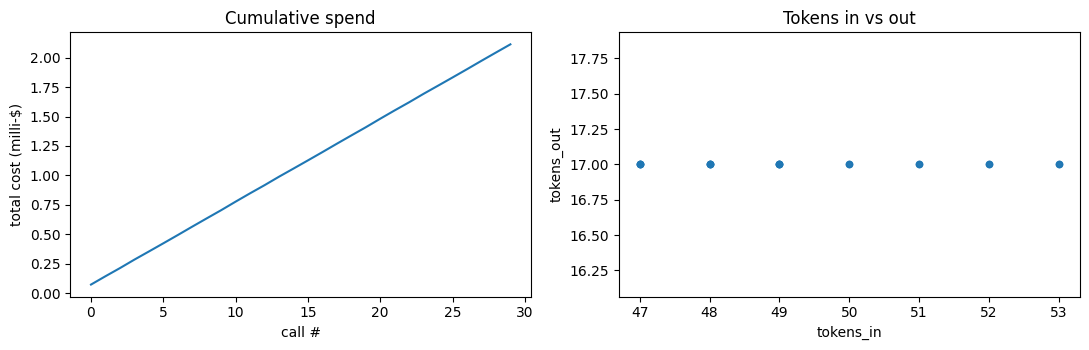

In [17]:
import matplotlib.pyplot as plt

trace_df = trace_df.sort_values("ts").reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
(trace_df["cost_usd"].cumsum() * 1000).plot(
    ax=axes[0], title="Cumulative spend", xlabel="call #", ylabel="total cost (milli-$)")
trace_df.plot.scatter(x="tokens_in", y="tokens_out", alpha=0.7, ax=axes[1],
                      title="Tokens in vs out")
fig.tight_layout()
plt.show()

**In ~40 lines you have what most teams pay per-seat for.** The hosted tools add real-time pipelines, alerts, and a UI — but the data model is this `trace_df`.

---

### ✋ Quick exercise (~2 min) — Forecast the monthly bill

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Finance wants a number. Using the per-call cost already in `trace_df["cost_usd"]`, estimate the **monthly** spend if this feature handles **50,000 calls per day** for **30 days**.

In [18]:
# ✍️ Your turn 👇
# mean cost per call * calls/day * days
monthly_usd = ...
# print(f"Forecast monthly cost: ${monthly_usd:.2f}")   # uncomment once monthly_usd is set

<details>
<summary>✅ <b>Solution</b></summary>

```python
monthly_usd = trace_df["cost_usd"].mean() * 50_000 * 30
print(f"Forecast monthly cost: ${monthly_usd:.2f}")
```

The trace already carries per-call cost, so a forecast is just mean-cost × volume — the same data model that powers the dashboard answers budget questions too. (These are mock micro-costs; plug in a real model's token counts and the number gets real.)
</details>

### 11. Regression test — refuse to ship if quality drops

Every piece now snaps into one loop: on any prompt or model change, re-run the golden set and **refuse to ship** if accuracy fell more than a small tolerance. This is a `pytest` for a probabilistic feature — the alarm that stops a Section-1 horror story before it reaches a customer.

In [19]:
def accuracy_on(prompt, golden_df):
    """Both-fields accuracy of a triage prompt on the golden set."""
    ok = 0
    for _, row in golden_df.iterrows():
        r = llm.chat(messages=[{"role": "system", "content": prompt},
                               {"role": "user",   "content": row["text"]}])
        try:
            pred = json.loads(r["text"])
        except json.JSONDecodeError:
            pred = {}                                   # unparseable reply = wrong
        if (pred.get("sentiment") == row["expected_sentiment"]
                and pred.get("topic") == row["expected_topic"]):
            ok += 1
    return ok / len(golden_df)

def regression_test(prompt, golden_df, baseline, tolerance=0.05):
    """Return True if the prompt is within `tolerance` of the baseline accuracy."""
    acc = accuracy_on(prompt, golden_df)
    passed = acc >= baseline - tolerance
    mark = "✅ PASS" if passed else "❌ FAIL — do NOT ship"
    print(f"{mark}: accuracy {acc:.0%} vs baseline {baseline:.0%} (tolerance {tolerance:.0%})")
    return passed

BASELINE = accuracy_on(SYSTEM, golden_df)
print(f"Frozen baseline accuracy: {BASELINE:.0%}\n")

print("Re-running the SAME prompt (should PASS):")
regression_test(SYSTEM, golden_df, BASELINE)

# A 'harmless' rewrite that quietly drops the JSON instruction -> the feature falls apart
BROKEN_PROMPT = "Tag each incoming message with a sentiment and a topic, however you see fit."
print("\nShipping a BROKEN prompt (should FAIL):")
regression_test(BROKEN_PROMPT, golden_df, BASELINE)

Frozen baseline accuracy: 70%

Re-running the SAME prompt (should PASS):
✅ PASS: accuracy 70% vs baseline 70% (tolerance 5%)

Shipping a BROKEN prompt (should FAIL):
❌ FAIL — do NOT ship: accuracy 0% vs baseline 70% (tolerance 5%)


False

> 🧠 **The discipline.** Bake `regression_test` into CI (`.github/workflows/eval.yml`) and a prompt change *cannot* silently regress production — the check exits non-zero, the merge is blocked, and a human investigates *before* the customer notices. The broken prompt above looks perfectly reasonable to a human; only the golden set caught that it stopped returning JSON.

**Stop and notice what we built.** Part 1 turned messy receipts into a scored table; Part 2 wrapped a live feature in a golden set, a judge, a trace, a cost dashboard, and a regression alarm. Together that's the whole loop from *"the model said something"* to *"and we can prove it's still working tomorrow."*

---
## 🧪 Practice exercises

Six exercises, easy → harder. Try each before opening the solution. The last one is a 🐞 debugger.

### Exercise 1 — ⭐ A field-accuracy helper

Write `field_accuracy(records, truth, field)` that returns the share of records whose `field` matches the ground truth (records are `Receipt` dataclasses; use `asdict`). Call it for `"order_id"` and `"amount"` and confirm it reproduces the numbers from Section 5.

In [20]:
# Your code here  👇
def field_accuracy(records, truth, field):
    ...

<details>
<summary>💡 <b>Solution</b></summary>

```python
def field_accuracy(records, truth, field):
    hits = sum(1 for rec, gold in zip(records, truth) if asdict(rec)[field] == gold[field])
    return hits / len(truth)

for f in ("order_id", "amount"):
    print(f"{f:<9}: {field_accuracy(receipts, GROUND_TRUTH, f):.0%}")
```

Pulling the per-field logic into a helper means you can score any field with one call — the first step toward a reusable extraction-eval harness.
</details>

### Exercise 2 — ⭐⭐ Confidence-aware extraction

Real document pipelines auto-process the confident records and route the rest to a human. Build `needs_review`, a list of the receipt indices whose `validate()` returns **any** error, and print how many need a human.

In [21]:
# Your code here  👇
needs_review = ...

<details>
<summary>💡 <b>Solution</b></summary>

```python
needs_review = [i for i, rec in enumerate(receipts) if validate(rec)]
print(f"{len(needs_review)} of {len(receipts)} receipts need human review: {needs_review}")
```

The "automation rate" — the share you process without a human touch — is the number document-AI teams actually optimise. Routing only clean records through automatically is how the economics work at scale.
</details>

### Exercise 3 — ⭐⭐ Per-class F1 for topic

A single accuracy number hides which class is weakest. Use `sklearn.metrics.f1_score(..., average=None, labels=[...])` on `eval_df` to compute the F1 per topic, and print which topic the feature is **worst** at.

In [22]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.metrics import f1_score
labels = ["billing", "tech", "feature", "other"]
f1 = f1_score(eval_df["expected_topic"], eval_df["predicted_topic"],
              labels=labels, average=None, zero_division=0)
scores = pd.Series(f1, index=labels).round(2)
print(scores.to_string())
print(f"\nWorst topic: {scores.idxmin()} (F1 = {scores.min():.2f})")
```

Per-class F1 is the right metric for imbalanced multi-class problems: it exposes the class the headline accuracy quietly averages away — exactly the bucket to focus your next prompt tweak on.
</details>

### Exercise 4 — ⭐⭐ A/B test two prompt variants

Never ship a new prompt on vibes. Run the baseline `SYSTEM` and a variant `SYSTEM_V2` (add a clarifying hint) against `golden_df`, and print both accuracies so you can compare honestly.

In [23]:
# Your code here  👇
SYSTEM_V2 = SYSTEM + " Be careful to distinguish feature requests from general feedback."

<details>
<summary>💡 <b>Solution</b></summary>

```python
SYSTEM_V2 = SYSTEM + " Be careful to distinguish feature requests from general feedback."
for name, prompt in [("v1_baseline", SYSTEM), ("v2_with_hint", SYSTEM_V2)]:
    print(f"{name:<14}: both-fields accuracy {accuracy_on(prompt, golden_df):.0%}")
```

Both variants score the same here (the mock ignores the extra hint), and that *is* the lesson: run the eval, don't guess. On a real model you'd also check tokens, latency, and cost didn't regress — a prompt that's 1pt more accurate but 2× slower may not be worth shipping.
</details>

### Exercise 5 — ⭐⭐ Trace-based cost forecast

Using `trace_df`, forecast the **monthly** cost if each traced call represents one *minute* of production traffic (i.e. 60 × 24 × 30 calls/month at the mean per-call cost).

In [24]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
mean_cost = trace_df["cost_usd"].mean()
calls_per_month = 60 * 24 * 30
print(f"Mean cost / call : ${mean_cost:.6f}")
print(f"Calls / month    : {calls_per_month:,}")
print(f"Forecast cost    : ${mean_cost * calls_per_month:,.2f}/month")
```

A forecast like this — done *before* you scale traffic — is what prevents the "we 10×'d load and the bill 10×'d too" surprise. The trace already has everything you need; the forecast is one multiply.
</details>

### Exercise 6 — ⭐⭐ Debug me 🐞

Run the cell below — **it crashes**. A real model wrapped its JSON answer in a chatty sentence, and this parser calls `json.loads` with no guard rail, so one bad reply takes down the whole batch. Find the bug and fix it so a malformed reply can't crash you.

In [25]:
import json
# A real model sometimes adds prose around the JSON. This reply is NOT valid JSON:
model_reply = 'Sure! Here is the JSON you asked for: {"sentiment": "positive", "topic": "feature"}'
parsed = json.loads(model_reply)   # 💥 JSONDecodeError — the prose isn't JSON
print(parsed)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

<details>
<summary>💡 <b>Solution</b></summary>

The bug is calling `json.loads` on raw model output with **no `try/except`** — the leading prose ("Sure! Here is the JSON…") is not valid JSON, so `json.loads` raises `JSONDecodeError` and the batch dies. Parse defensively: isolate the JSON and fall back instead of crashing.

```python
import json, re

def safe_json(text, fallback=None):
    if not text:
        return fallback
    m = re.search(r"\{.*\}", text, re.DOTALL)   # grab the first {...} block if present
    try:
        return json.loads(m.group(0) if m else text)
    except json.JSONDecodeError:
        return fallback

print(safe_json(model_reply))                                  # {'sentiment': 'positive', 'topic': 'feature'}
print(safe_json("total nonsense", fallback={"sentiment": "unknown"}))  # {'sentiment': 'unknown'}
```

**Lesson.** Every batch will have *some* malformed replies. Defensive parsing — grab the `{...}`, `try/except`, fall back — keeps one bad response from killing the whole job. This is the same `try/except` habit from Part 1, now with a regex to salvage JSON hidden in prose.
</details>

---
## 🧠 Stretch exercises

Because this notebook combines two chapters, here is one deeper exercise from each — a **doc-AI** stretch and an **eval** stretch. Both are self-contained (they don't depend on earlier cells). Try them before opening the solution.

### Stretch exercise C — ⭐⭐⭐ Parse a messy line-item table with regex

Not every document is free prose — plenty arrive as semi-structured tables. Parse the receipt log below into a list of dicts with keys `date`, `category`, `amount`. The format is rigid enough for a single regex, but the padding is sloppy.

```
2024-01-12 | hosting  | 1240.00
2024-01-12 | catering |  700.00
2024-01-13 | ads      | 4650.00
```

In [26]:
# Your code here  👇
LOG = """
2024-01-12 | hosting  | 1240.00
2024-01-12 | catering |  700.00
2024-01-13 | ads      | 4650.00
""".strip()

import re
rows = []
# ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
LOG = """
2024-01-12 | hosting  | 1240.00
2024-01-12 | catering |  700.00
2024-01-13 | ads      | 4650.00
""".strip()

import re
pattern = re.compile(r"^(\d{4}-\d{2}-\d{2})\s*\|\s*(\w+)\s*\|\s*([\d.]+)$")
rows = []
for line in LOG.splitlines():
    m = pattern.match(line)
    if m:
        date, category, amount = m.groups()
        rows.append({"date": date, "category": category, "amount": float(amount)})

for r in rows:
    print(r)
```

**Reasoning.** Three regex habits. (1) **Anchor with `^` and `$`** when each line is a complete record, so a stray character yields no partial match. (2) **`\s*` around the `|` delimiters** absorbs the variable padding (`'hosting  '` vs `'ads      '`) — always assume your separator is sloppy. (3) **`re.compile` once, use many times** — faster and self-documenting. For genuinely drifting formats, reach for a parser (`pyparsing`) or a real log-aggregation tool rather than an ever-growing regex.
</details>

### Stretch exercise D — ⭐⭐⭐ Exact-match vs case-insensitive vs semantic

The metric you pick decides whether an answer is "wrong". Score the same output against three correctness metrics and see how the verdict changes.

```python
expected = "Refunds are issued within 5 business days."
actual   = "refunds are issued within five business days"
```

Compute **(1)** exact match, **(2)** case-insensitive substring match, **(3)** token-overlap Jaccard, and print all three.

In [27]:
# Your code here  👇
expected = "Refunds are issued within 5 business days."
actual   = "refunds are issued within five business days"

# ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import re
expected = "Refunds are issued within 5 business days."
actual   = "refunds are issued within five business days"

exact = (expected == actual)
ci_substring = expected.strip(".").lower() in actual.lower()

def toks(s):
    return set(re.findall(r"[a-z0-9]+", s.lower()))
jaccard = len(toks(expected) & toks(actual)) / max(1, len(toks(expected) | toks(actual)))

print(f"exact match           : {exact}")
print(f"case-insensitive sub  : {ci_substring}")
print(f"Jaccard token overlap : {jaccard:.2f}")
```

**Reasoning.** Three metrics, three failure modes. (1) **Exact match** is strictest — it fails here on `5` vs `five` and the missing period; use it only for structured output you control. (2) **Case-insensitive substring** forgives casing and punctuation but still can't see `5 ↔ five`. (3) **Jaccard token overlap** forgives word order and small edits but treats every word as equal, including `the`. Real eval pipelines combine them: exact-match on a held-out structured field, plus an LLM-as-judge on the free-text portion — which is exactly the two-tool split this notebook is built around.
</details>

---
## 🧠 Key takeaways

Two safeguards, one habit — that's the whole notebook:

1. **Structured-output prompting** turns messy documents into typed records: tell the model the exact JSON shape, and its answer drops straight into the next stage.
2. **Always wrap `json.loads` in `try/except`.** One malformed reply must never crash a batch — return a fallback and keep going.
3. **Validate every record** against a dataclass + schema (types, ranges) — *but* validation checks **shape, not truth**: a well-formed wrong value still passes.
4. **Field-level accuracy vs ground truth** is your honest correctness metric; the worst field sets the pipeline's floor.
5. **A golden set is the most important eval artefact.** Freeze known-correct examples before you ship; grow it whenever a real user reports a bad output.
6. **Break accuracy open per class** — a confusion table names the exact failure mode a single number hides.
7. **LLM-as-judge** scores free text, but the judge is a biased model you must validate, not an oracle.
8. **Trace every call** (prompt hash, tokens, latency) → a **cost dashboard** and a monthly forecast are then a couple of `groupby`s away.
9. **A regression test** re-runs the golden set on every change and refuses to ship when quality drops. Bake it into CI.

> 🧭 **The mental model, one last time.** Extract structure, then trust nothing until it's validated; and you can't improve what you don't measure, so freeze a golden set *before* you touch the prompt. Do both and an AI feature becomes as boring — as *reliable* — as any other code.

## ✅ Self-assessment

- [ ] Write a structured-output prompt and parse the reply with `try/except`
- [ ] Normalise + validate an extracted record against a dataclass/schema
- [ ] Explain why a record can pass validation yet still be wrong
- [ ] Compute field-level accuracy against ground truth
- [ ] Build a golden set and score a feature with overall + per-class metrics
- [ ] Explain when LLM-as-judge is the right metric — and its biases
- [ ] Capture a trace row per call and compute cost + p95 latency from it
- [ ] Write a regression test that fails when golden-set accuracy drops

## 🚀 Next step

Continue with **Notebook 19 (fast track) — NLP: Topic Modeling & Sentiment**.

For the full treatment of either half — PDF extraction and chunking, or A/B-testing statistics, bias mitigation, and CI wiring — see the canonical **Module 6 · AI Engineering** chapters this notebook combines: [`25_document_processing.ipynb`](../06_ai_engineering/25_document_processing.ipynb) and [`26_ai_evaluation_observability.ipynb`](../06_ai_engineering/26_ai_evaluation_observability.ipynb).